In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [71]:
df = pd.read_csv("../dataset/APL_Logistics.csv", encoding="latin1")
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [72]:
df.shape

(180519, 40)

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Fname                 180519 non-null  str    
 12  Customer Id                    180519 non

In [74]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107607,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,6691.379495,20.664741,0.101668,141.232547,0.120647,2.127638,203.772092,183.107607,21.974989,141.232547
std,1.623722,1.374449,104.433526,120.043668,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,4162.918106,21.800901,0.070415,139.732489,0.466796,1.453451,132.273075,120.043668,104.433526,139.732489
min,0.000000,0.000000,-4274.980000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.980000,9.990000
25%,2.000000,2.000000,7.000000,104.380000,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,3258.500000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980000,104.380000,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990000,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,6457.000000,14.000000,0.100000,59.990000,0.270000,1.000000,199.920000,163.990000,31.520000,59.990000
75%,5.000000,4.000000,64.800000,247.400000,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,9779.000000,29.990000,0.160000,199.990000,0.360000,3.000000,299.950000,247.400000,64.800000,199.990000
max,6.000000,4.000000,911.800000,1939.990000,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,20757.000000,500.000000,0.250000,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1999.990000


In [75]:
missing = df.isnull().sum()
missing[missing > 0]

Customer Lname      8
Customer Zipcode    3
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df["Shipping Delay"] = (
    df["Days for shipping (real)"] -
    df["Days for shipment (scheduled)"]
)

df["Shipping Delay"].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Shipping Delay, dtype: float64

In [78]:
df["Discount (%)"] = df["Order Item Discount Rate"] * 100

In [79]:
df["Customer Type"] = np.where(
    df["Benefit per order"] > 0,
    "Profitable",
    "Loss Making"
)

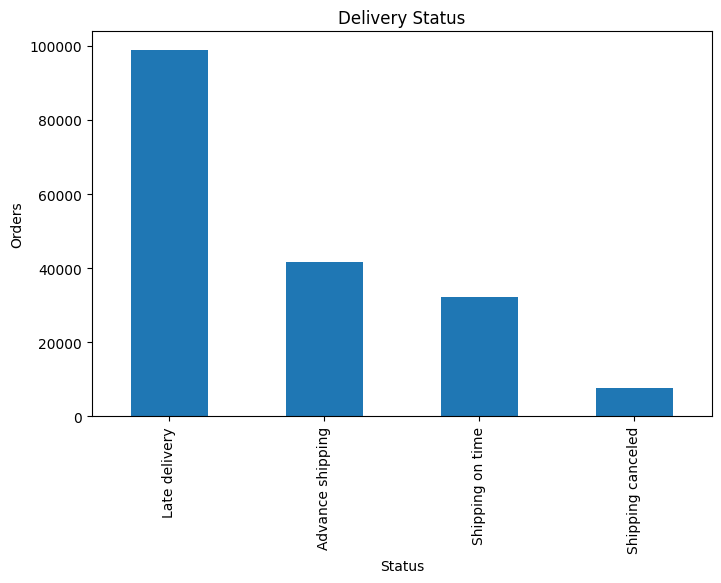

In [80]:
plt.figure(figsize=(8,5))

df["Delivery Status"].value_counts().plot(kind="bar")

plt.title("Delivery Status")
plt.xlabel("Status")
plt.ylabel("Orders")
plt.show()

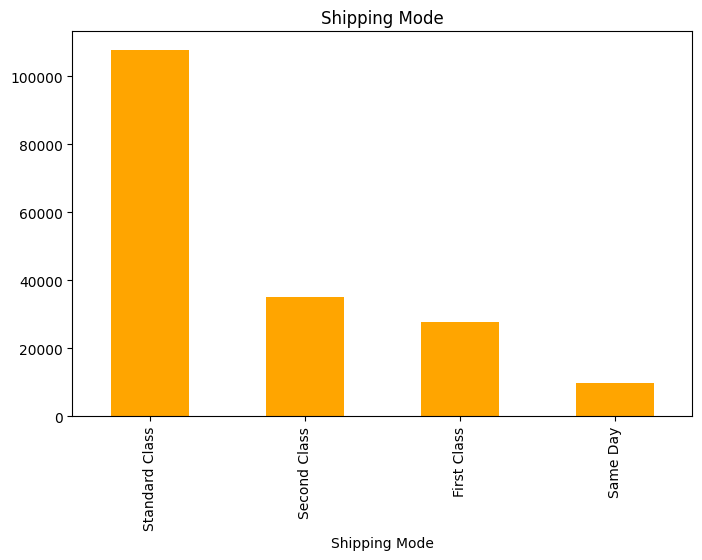

In [81]:
plt.figure(figsize=(8,5))

df["Shipping Mode"].value_counts().plot(kind="bar", color="orange")

plt.title("Shipping Mode")
plt.show()

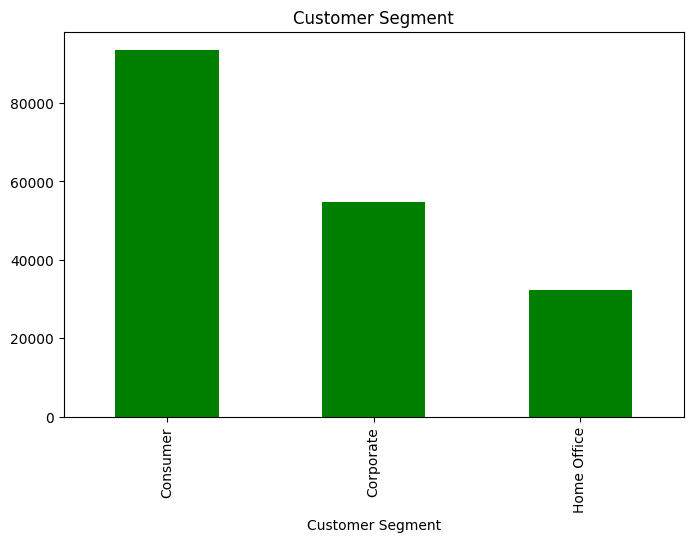

In [82]:
plt.figure(figsize=(8,5))

df["Customer Segment"].value_counts().plot(kind="bar", color="green")

plt.title("Customer Segment")
plt.show()

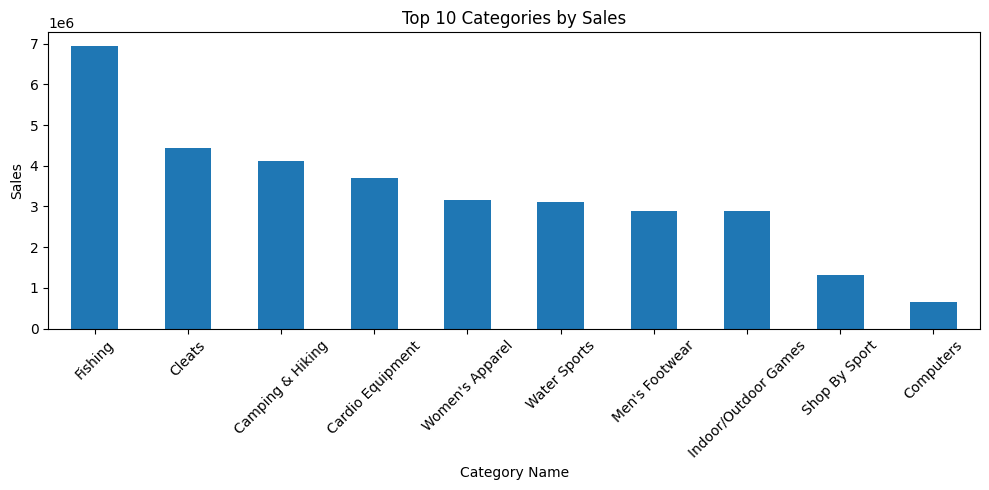

In [83]:
category_sales = (
    df.groupby("Category Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

category_sales.plot(kind="bar")

plt.title("Top 10 Categories by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

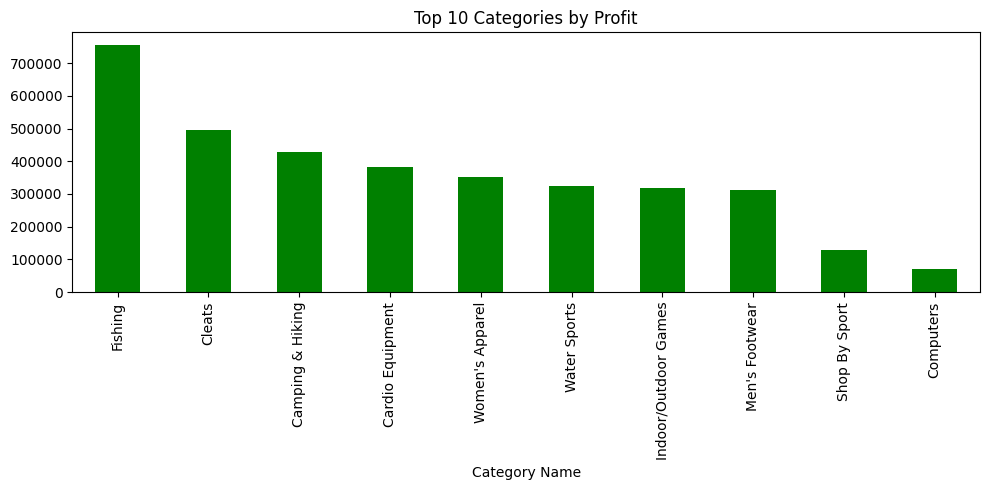

In [84]:
category_profit = (
    df.groupby("Category Name")["Benefit per order"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

category_profit.plot(kind="bar", color="green")

plt.title("Top 10 Categories by Profit")

plt.tight_layout()
plt.show()

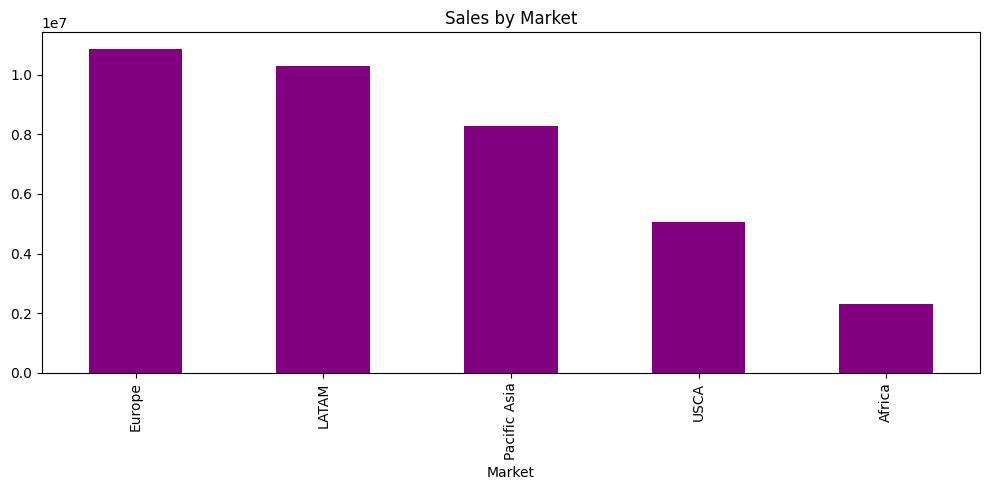

In [85]:
market_sales = (
    df.groupby("Market")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

market_sales.plot(kind="bar", color="purple")

plt.title("Sales by Market")

plt.tight_layout()
plt.show()

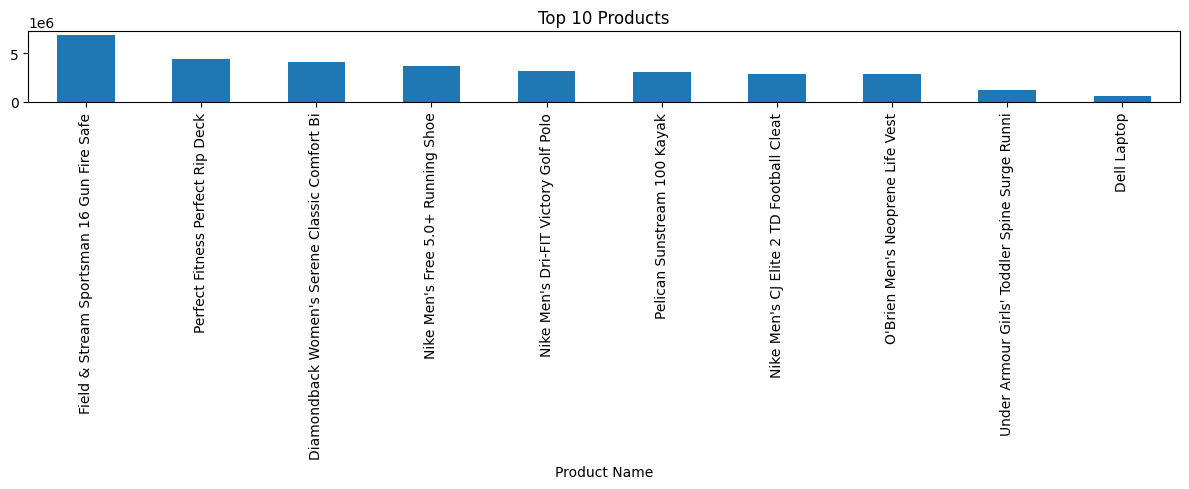

In [86]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products")

plt.tight_layout()
plt.show()

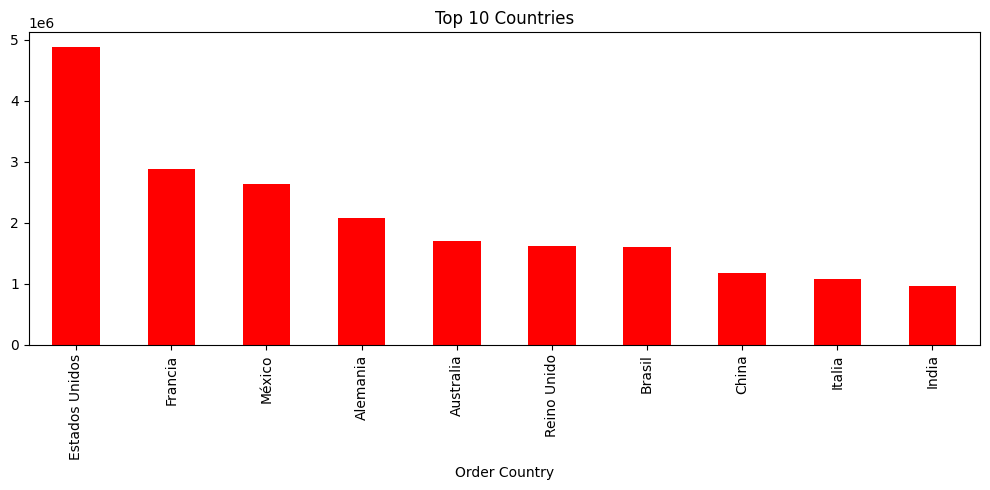

In [87]:
country_sales = (
    df.groupby("Order Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

country_sales.plot(kind="bar", color="red")

plt.title("Top 10 Countries")

plt.tight_layout()
plt.show()

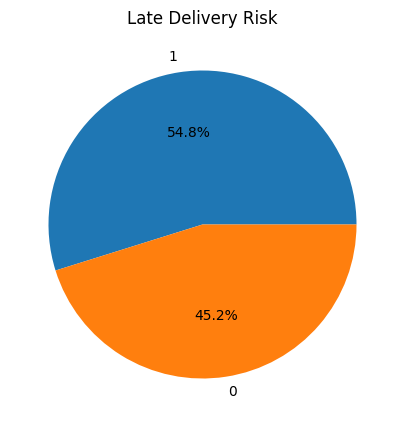

In [88]:
plt.figure(figsize=(6,5))

df["Late_delivery_risk"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Late Delivery Risk")

plt.show()

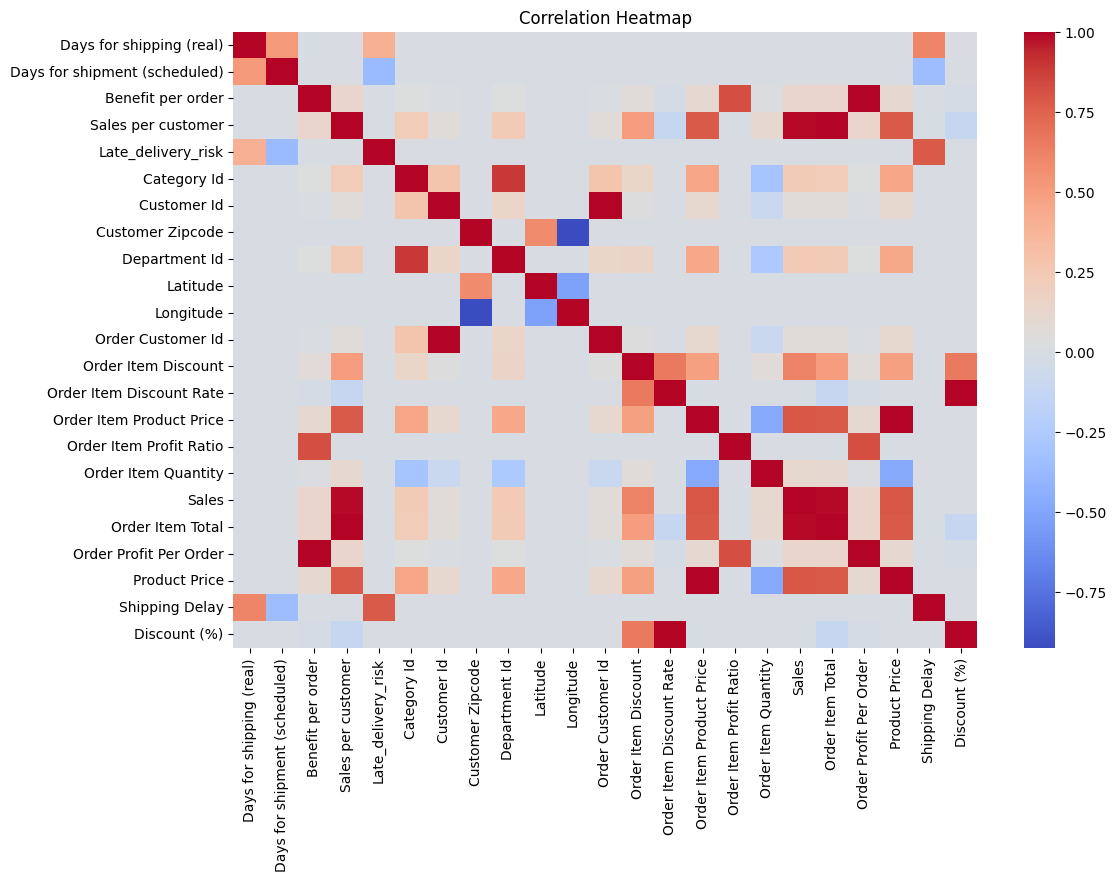

In [89]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [90]:
print("========== KPI SUMMARY ==========")

print("Total Orders :", len(df))
print("Total Sales :", round(df["Sales"].sum(), 2))
print("Total Profit :", round(df["Benefit per order"].sum(), 2))
print("Average Sales :", round(df["Sales"].mean(), 2))
print("Average Profit :", round(df["Benefit per order"].mean(), 2))
print("Average Discount :", round(df["Discount (%)"].mean(), 2), "%")
print("Average Shipping Delay :", round(df["Shipping Delay"].mean(), 2), "Days")

========== KPI SUMMARY ==========
Total Orders : 180519
Total Sales : 36784734.31
Total Profit : 3966902.97
Average Sales : 203.77
Average Profit : 21.97
Average Discount : 10.17 %
Average Shipping Delay : 0.57 Days
